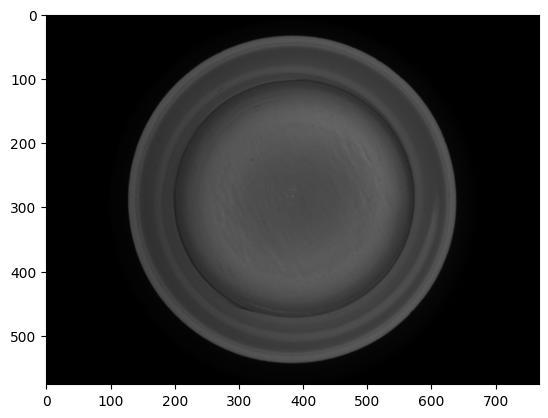

CAP OUTLINE - center: x=  383.5  y=  288.5  , radius=  255.3


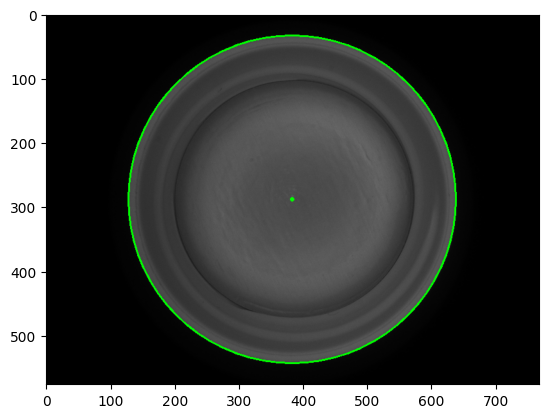

LINER - center: x=  388.5  y=  286.5  , radius=  185.8


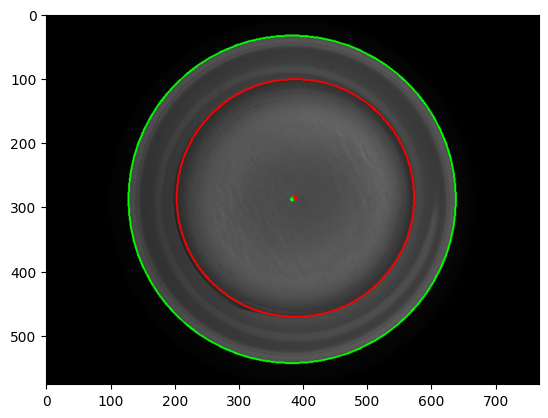

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

#### LOAD and show IMAGE
img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/g_06.bmp')
img = cv2.cvtColor(img_color,cv2.COLOR_BGR2GRAY)
plt.figure()
plt.imshow(img,cmap='gray',vmin=0,vmax=255)
plt.show()

#### histogram 
hist, bins = np.histogram(img.flatten(), 256, [0,256])
'''
plt.figure(2,figsize=[8,4])
plt.stem(hist)
plt.show()
'''
######## TASK 1.1:  Outline the cap by generating a circle that fits the cap mouth #########
img_blur = cv2.GaussianBlur(img,(7,7),0)
circles = cv2.HoughCircles(img_blur,cv2.HOUGH_GRADIENT, 1, 45,param1=70,param2=70) # ok per trovare esterno dei tappi
# param1: threshold della differenza del gradiente (+alto = colori + diversi)
# param2 : perfezione del cerchio
#print(circles, circles.shape)
center = (circles[0][0][0],circles[0][0][1])
radius = circles[0][0][2]
'''for c in circles[0,:] : 
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(c[2]),color=(0, 255, 0),thickness=2)
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(2),color=(0, 255, 0),thickness=2)
    print("center: x= ", c[0]," y= ",c[1]," - radius= ",c[2])
'''

cv2.circle(img_color,(int(center[0]),int(center[1])),int(radius),color=(0, 255, 0),thickness=2)
cv2.circle(img_color,(int(center[0]),int(center[1])),int(2),color=(0, 255, 0),thickness=2)
print("CAP OUTLINE - center: x= ", center[0]," y= ",center[1]," , radius= ",radius )
plt.imshow(img_color)
plt.show()

########## TASK 1.2 : identifica rotture liner

edges = cv2.Canny(img,50,100,apertureSize = 3)
#plt.imshow(edges,cmap='gray',vmin=0,vmax=255)
#plt.show() 


lines = cv2.HoughLines(edges,1,np.pi/180,70)
if lines is not None and len(lines) > 0:
    #
    #for line in lines:
        #rho, theta = line[0]
        #a = np.cos(theta)
        #b = np.sin(theta)
        #x0 = a * rho
        #y0 = b * rho
        #x1 = int(x0 + 1000 * (-b))
        #y1 = int(y0 + 1000 * (a))
        #x2 = int(x0 - 1000 * (-b))
        #y2 = int(y0 - 1000 * (a))

        #cv2.line(img_color, (x1, y1), (x2, y2), (0, 0, 255), 2)
    
    rho, theta = lines[0][0] 
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    
    cv2.line(img_color, (x1, y1), (x2, y2), (0, 0, 255), 2)
    print(x0,y0)
    plt.figure()
    plt.imshow(img_color)
    plt.show()

    #### funziona bene con tutte c'è solo da capire come fare il rettangolo

'''# houghlinesP : fa le linee "limitate" non infinite ma è peggio a prendere le linee complete perchè sono un po' stortine
linesP = cv2.HoughLinesP(edges,1,np.pi/180,60,minLineLength=50,maxLineGap=60)
#linesP = cv2.HoughLinesP(edges,1,np.pi/180,50,minLineLength=50,maxLineGap=58) # perfetta per d17

if linesP is not None and len(linesP) > 0:
    #
    for line in linesP:
        x1,y1,x2,y2= line[0]
        cv2.line(img_color, (x1, y1), (x2, y2), (0, 0, 255), 2)
  

    #x1,y1,x2,y2 = linesP[0][0] 
    #cv2.line(img_color, (x1, y1), (x2, y2), (0, 0, 255), 2)
   
    plt.figure()
    plt.imshow(img_color)
    plt.show()
'''



    


##### TASK 1.3: missing liner
'''
fare region of interest nel cerchio piccolo (si può fare circolare)
fare la avg lightness di altre immagini e trovare il valore medio più diffuso e se è più chiara allora è senza liner  
'''


######## TASK 2:  Outline the cap by generating a circle that fits the cap mouth ######### !!!!!!!!!!!11 d_31 questa non la trova (che ci sta che sia così)
circles_in = cv2.HoughCircles(img_blur,cv2.HOUGH_GRADIENT, 1, 45,param1=50,param2=40,maxRadius=int(radius*0.9)) # ok per trovare liner ma forse è un po' barare con min radius
# param1: threshold della differenza del gradiente (+alto = colori + diversi)
# param2 : perfezione del cerchio
#print(circles, circles.shape)
for c in circles_in[0,:] : 
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(c[2]),color=(255, 0, 0),thickness=2)
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(2),color=(255,0, 0),thickness=2)
    print("LINER - center: x= ", c[0]," y= ",c[1]," , radius= ",c[2])

plt.imshow(img_color)
plt.show()
